# Comparing Naive Bayes Variants on the Breast Cancer Dataset

In this notebook, we train **GaussianNB**, **MultinomialNB**, and **BernoulliNB** on the exact same Breast Cancer dataset and the exact same train/test split, so we can compare them fairly.

## Libraries

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import confusion_matrix ,classification_report , accuracy_score

## Load Dataset

In [27]:
df=load_breast_cancer()

In [28]:
X=df.data

In [29]:
X.shape

(569, 30)

In [30]:
y=df.target

In [59]:
target_names =df.target_names

## Train/Test Split

In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y, train_size=0.8,random_state=42
)

## Models Training

In [32]:
GaussianNBModel=GaussianNB()
MultinomialNBModel = MultinomialNB(alpha=1.0)
BernoulliNBModel = BernoulliNB(binarize=8.0)

## GaussianNB

In [53]:
GaussianNBModel = GaussianNB()
GaussianNBModel.fit(X_train, y_train)

gnb_train_pred = GaussianNBModel.predict(X_train)
gnb_test_pred = GaussianNBModel.predict(X_test)

gnb_train_acc = accuracy_score(y_train, gnb_train_pred)
gnb_test_acc = accuracy_score(y_test, gnb_test_pred)
print(f'{gnb_train_acc:.2f} , {gnb_test_acc:.2f}')

0.94 , 0.97


## MultinomialNB

In [54]:
MultinomialNBModel = MultinomialNB()
MultinomialNBModel.fit(X_train, y_train)

mnb_train_pred = MultinomialNBModel.predict(X_train)
mnb_test_pred = MultinomialNBModel.predict(X_test)

mnb_train_acc = accuracy_score(y_train, mnb_train_pred)
mnb_test_acc = accuracy_score(y_test, mnb_test_pred)
print(f'{mnb_train_acc:.2f} , {mnb_test_acc:.2f}')

0.89 , 0.94


## BernoulliNB

In [56]:
BernoulliNBModel = BernoulliNB(binarize= np.median(X_train))
BernoulliNBModel.fit(X_train, y_train)

bnb_train_pred = BernoulliNBModel.predict(X_train)
bnb_test_pred = BernoulliNBModel.predict(X_test)

bnb_train_acc = accuracy_score(y_train, bnb_train_pred)
bnb_test_acc = accuracy_score(y_test, bnb_test_pred)
print(f'{bnb_train_acc:.2f} , {bnb_test_acc:.2f}')

0.84 , 0.84


## Evaluate

In [57]:
print('--- GaussianNB ---')
print(classification_report(y_test, gnb_test_pred))

print('--- MultinomialNB ---')
print(classification_report(y_test, mnb_test_pred))

print('--- BernoulliNB ---')
print(classification_report(y_test, bnb_test_pred))

--- GaussianNB ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

--- MultinomialNB ---
              precision    recall  f1-score   support

           0       1.00      0.84      0.91        43
           1       0.91      1.00      0.95        71

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

--- BernoulliNB ---
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        43
           1       0.85      0.90      0.88        71

    accuracy                           0.84       114
   macro avg       0.84      0.82      0.83       114
weighted avg 

## Confusion Matrix

Text(978.81045751634, 0.5, 'Actual')

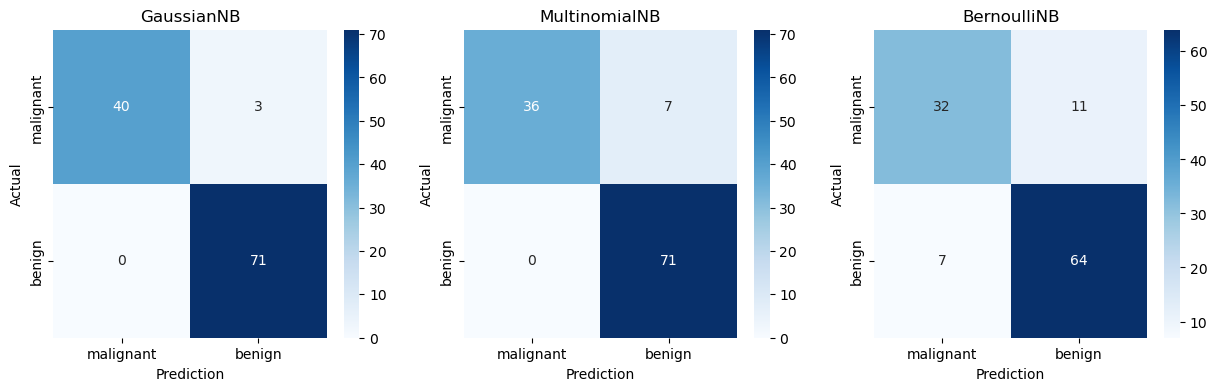

In [60]:
CM_gnb = confusion_matrix(y_test, gnb_test_pred)
CM_mnb = confusion_matrix(y_test, mnb_test_pred)
CM_bnb = confusion_matrix(y_test, bnb_test_pred)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.heatmap(CM_gnb, annot=True, fmt='g', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title('GaussianNB')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Actual')

sns.heatmap(CM_mnb, annot=True, fmt='g', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('MultinomialNB')
axes[1].set_xlabel('Prediction')
axes[1].set_ylabel('Actual')

sns.heatmap(CM_bnb, annot=True, fmt='g', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[2])
axes[2].set_title('BernoulliNB')
axes[2].set_xlabel('Prediction')
axes[2].set_ylabel('Actual')


## Accuracy Summary Table

| Model | Train | Test |Verdict |
|---|---|---|---|
| GaussianNB | 0.94 | 0.97 |  **Good fit** |
| MultinomialNB | 0.89 | 0.94 |**Mild underfitting** |
| BernoulliNB | 0.84 | 0.84 |  **Clear underfitting** |

## Conclusion

On the exact same data and split, the three models perform quite differently:

- **GaussianNB (97% test accuracy)** — the clear winner, as expected: the 30 continuous cell-measurement features are exactly what `GaussianNB` assumes.
- **MultinomialNB (94% test accuracy)** — still strong, but its **recall for malignant tumors drops to 84%** (compared to GaussianNB's 93%). In a medical context, those are malignant cases the model misses.
- **BernoulliNB (84% test accuracy)** — clearly the weakest here. Reducing all 30 continuous features to a single binary cut (median) loses most of the fine-grained information that separates malignant from benign tumors.

**Key takeaway:** `GaussianNB` wins because the data is continuous, not because it's a universally "better" algorithm. For a medical diagnosis dataset like this one, the drop in malignant-tumor recall for `MultinomialNB` and `BernoulliNB` isn't just a number — it's a meaningfully worse safety margin.